# Heart Attack Prediction in Young Indians

**Dataset:** `heart_attack_youngsters_india.csv`  
**Goal:** Predict whether a young person is likely to have a heart attack based on their lifestyle, clinical tests, and demographic details.


In [14]:

# ── Standard data science stack ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Scikit-learn: preprocessing ───────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# ── Scikit-learn: models ───────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# ── Imbalanced-learn: SMOTE oversampling ──────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── Scikit-learn: evaluation ───────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# ── Plot aesthetics ────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

# ── Load the dataset ───────────────────────────────────────────────────────────
df = pd.read_csv(r"heart_attack_youngsters_india.csv")

print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()


Shape: (10000, 26)

Column names:
 ['Age', 'Gender', 'Region', 'Urban/Rural', 'SES', 'Smoking Status', 'Alcohol Consumption', 'Diet Type', 'Physical Activity Level', 'Screen Time (hrs/day)', 'Sleep Duration (hrs/day)', 'Family History of Heart Disease', 'Diabetes', 'Hypertension', 'Cholesterol Levels (mg/dL)', 'BMI (kg/m²)', 'Stress Level', 'Blood Pressure (systolic/diastolic mmHg)', 'Resting Heart Rate (bpm)', 'ECG Results', 'Chest Pain Type', 'Maximum Heart Rate Achieved', 'Exercise Induced Angina', 'Blood Oxygen Levels (SpO2%)', 'Triglyceride Levels (mg/dL)', 'Heart Attack Likelihood']

First 5 rows:


,Age,Gender,Region,Urban/Rural,SES,Smoking Status,Alcohol Consumption,Diet Type,Physical Activity Level,Screen Time (hrs/day),...,Stress Level,Blood Pressure (systolic/diastolic mmHg),Resting Heart Rate (bpm),ECG Results,Chest Pain Type,Maximum Heart Rate Achieved,Exercise Induced Angina,Blood Oxygen Levels (SpO2%),Triglyceride Levels (mg/dL),Heart Attack Likelihood
0,30,Male,East,Urban,Middle,Never,Regularly,Non-Vegetarian,Sedentary,3,...,High,177.0/63.1,82,Normal,Non-anginal,183,No,94.1,58,No
1,24,Female,East,Urban,Low,Occasionally,Occasionally,Non-Vegetarian,Sedentary,15,...,High,137.5/110.7,76,Normal,Non-anginal,118,No,97.1,341,No
2,24,Female,North,Urban,Low,Occasionally,Occasionally,Vegan,High,15,...,Low,138.3/76.6,86,Normal,Typical,164,No,92.7,373,Yes
3,27,Male,East,Urban,Middle,Occasionally,Never,Vegetarian,Sedentary,6,...,Medium,177.1/90.0,106,Normal,Non-anginal,188,No,98.4,102,Yes
4,21,Female,West,Rural,Low,Occasionally,Occasionally,Vegetarian,Moderate,4,...,Low,130.7/108.8,73,Normal,Atypical,216,No,94.9,235,No


In [15]:
# ── Basic info: data types, null counts, memory ───────────────────────────────
print("Data types and null counts:")  
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())  ##Count how many missing values
print("\nBasic statistics (numerical columns):")  #summary statistics for numerical columns
df.describe()

Data types and null counts:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Age                                       10000 non-null  int64  
 1   Gender                                    10000 non-null  str    
 2   Region                                    10000 non-null  str    
 3   Urban/Rural                               10000 non-null  str    
 4   SES                                       10000 non-null  str    
 5   Smoking Status                            10000 non-null  str    
 6   Alcohol Consumption                       10000 non-null  str    
 7   Diet Type                                 10000 non-null  str    
 8   Physical Activity Level                   10000 non-null  str    
 9   Screen Time (hrs/day)                     10000 non-null  int64  
 10  Sleep Duration (hr

,Age,Screen Time (hrs/day),Sleep Duration (hrs/day),Cholesterol Levels (mg/dL),BMI (kg/m²),Resting Heart Rate (bpm),Maximum Heart Rate Achieved,Blood Oxygen Levels (SpO2%),Triglyceride Levels (mg/dL)
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,26.601500,7.510700,6.489600,199.649000,27.44190,89.493400,159.683900,94.940730,275.010100
std,5.164239,4.626578,2.289327,57.561902,7.22374,17.318237,35.034037,2.883329,128.825994
min,18.000000,0.000000,3.000000,100.000000,15.00000,60.000000,100.000000,90.000000,50.000000
25%,22.000000,4.000000,4.000000,150.000000,21.20000,74.000000,129.000000,92.400000,164.000000
50%,27.000000,8.000000,6.000000,199.000000,27.50000,90.000000,160.000000,94.900000,277.000000
75%,31.000000,12.000000,8.000000,249.000000,33.70000,104.000000,190.000000,97.400000,385.000000
max,35.000000,15.000000,10.000000,300.000000,40.00000,119.000000,220.000000,100.000000,500.000000


## Step 2 — Exploratory Data Analysis (EDA)

**What:** We create charts to visually explore the data before building any model.

**Why:** We need to understand the data first:
- Is the data **balanced** — roughly equal Yes and No cases? Or skewed?
- Which **categories** (gender, smoking, diet, etc.) are most common?
- How are **numbers** like age, BMI, and cholesterol spread out?
- Are any two features **highly correlated** (which could confuse the model)?

**We look at four things:**
1. Target class distribution — how many Yes vs No cases?
2. Categorical features vs heart attack — e.g., do smokers have more attacks?
3. Numerical feature distributions — spread of age, BMI, cholesterol, etc.
4. Correlation heatmap — which numbers move together?

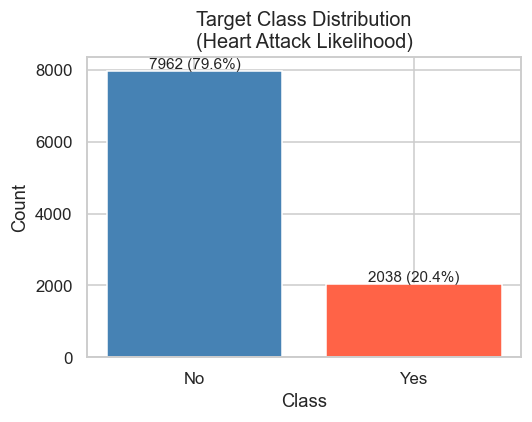

Heart Attack Likelihood
No     7962
Yes    2038
Name: count, dtype: int64


In [16]:
# ── 2a. Target class distribution ─────────────────────────────────────────────
# WHY: Knowing class balance is critical. If one class dominates, accuracy alone is misleading
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["Heart Attack Likelihood"].value_counts()
ax.bar(counts.index, counts.values, color=["steelblue", "tomato"], edgecolor="white")
ax.set_title("Target Class Distribution\n(Heart Attack Likelihood)", fontsize=13)
ax.set_xlabel("Class")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v + 60, f"{v} ({v/len(df)*100:.1f}%)", ha="center", fontsize=10)
plt.tight_layout()
plt.show()
print(counts)

**Class Distribution:**  
The bar chart shows how many people in the dataset had a heart attack (Yes) vs didn't (No).  
As one bar is much larger than the other, the dataset is **imbalanced** — we use Synthetic Minority Over-sampling Technique (SMOTE) to learn the minority class properly.  

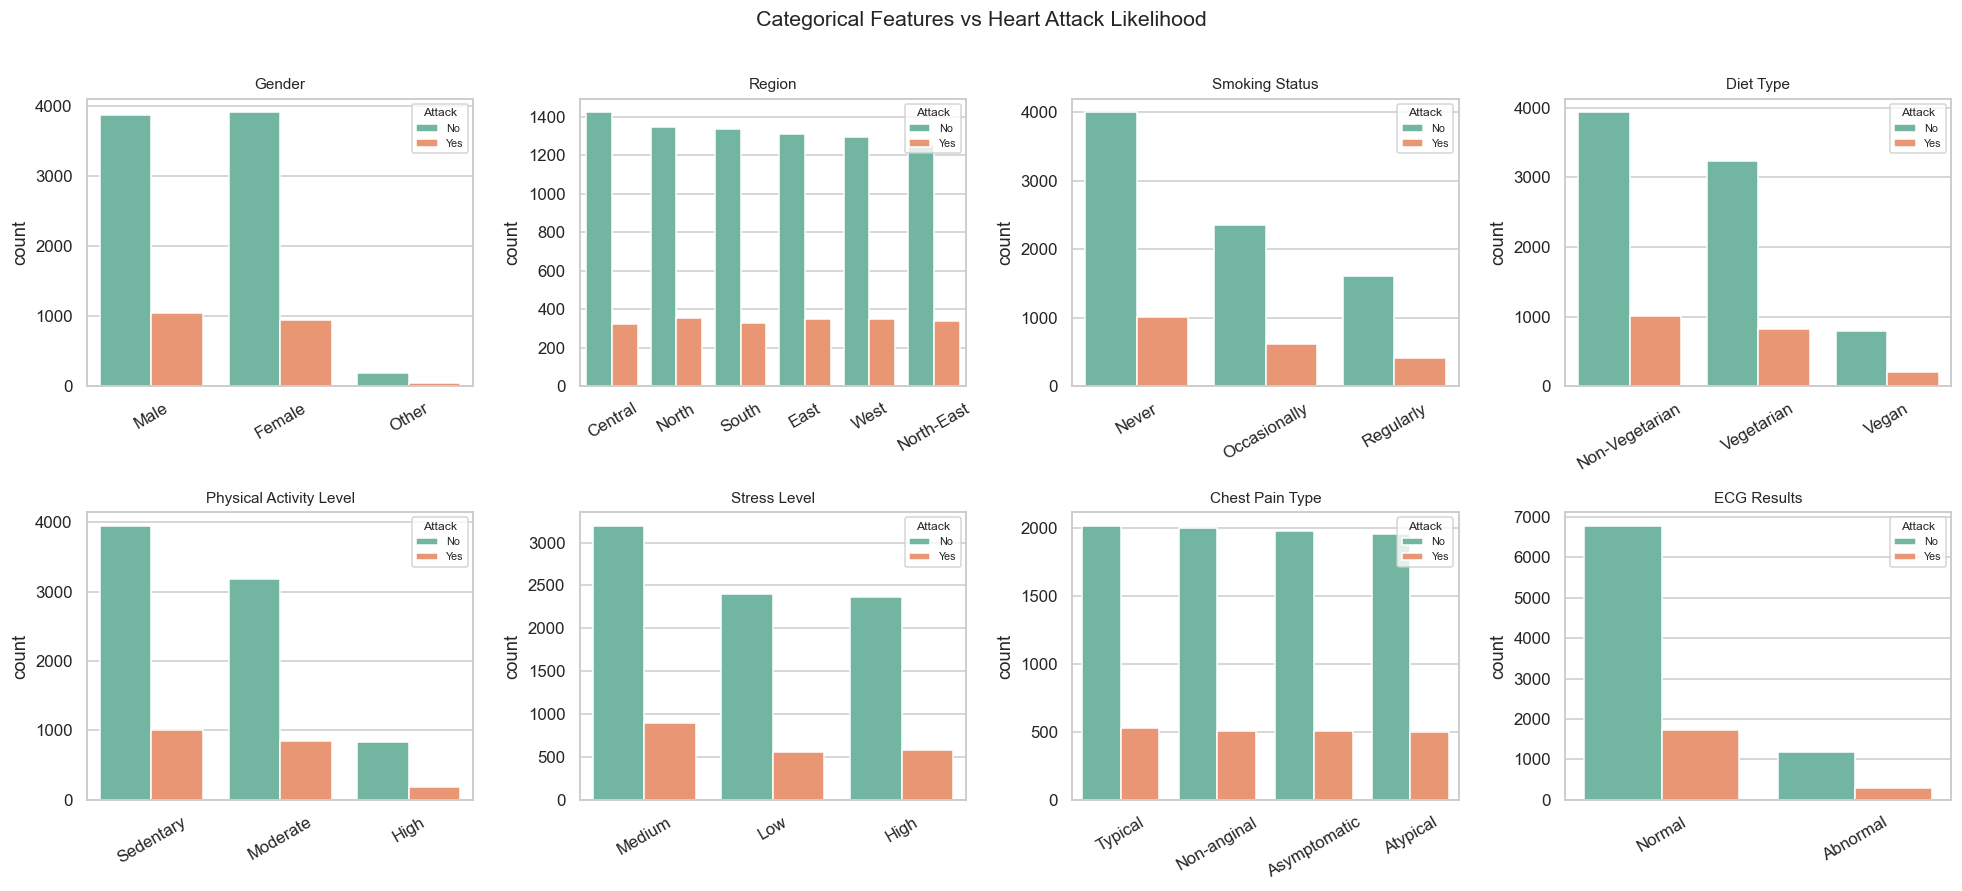

In [17]:
# ── 2b. Categorical feature count plots ───────────────────────────────────────
# WHY: These plots reveal dominant categories and show how lifestyle factors
#      (smoking, diet, activity) distribute across the dataset.
     #See which categories dominate the dataset (e.g., more males than females).
     #Check how the target variable (“Heart Attack Likelihood”) varies across those categories.
     #Identify potential risk factors or patterns (like smokers having higher heart attack probability).
cat_cols = ["Gender", "Region", "Smoking Status", "Diet Type", "Physical Activity Level",
            "Stress Level", "Chest Pain Type", "ECG Results"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, hue="Heart Attack Likelihood",
                  ax=axes[i], order=order, palette="Set2")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].legend(title="Attack", fontsize=7, title_fontsize=8)

plt.suptitle("Categorical Features vs Heart Attack Likelihood", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

- If the bars for Yes and No are roughly equal within a category, that feature may not be a strong predictor.  
- If one category strongly leans toward Yes (e.g., high stress → more Yes), it's an important risk factor.  

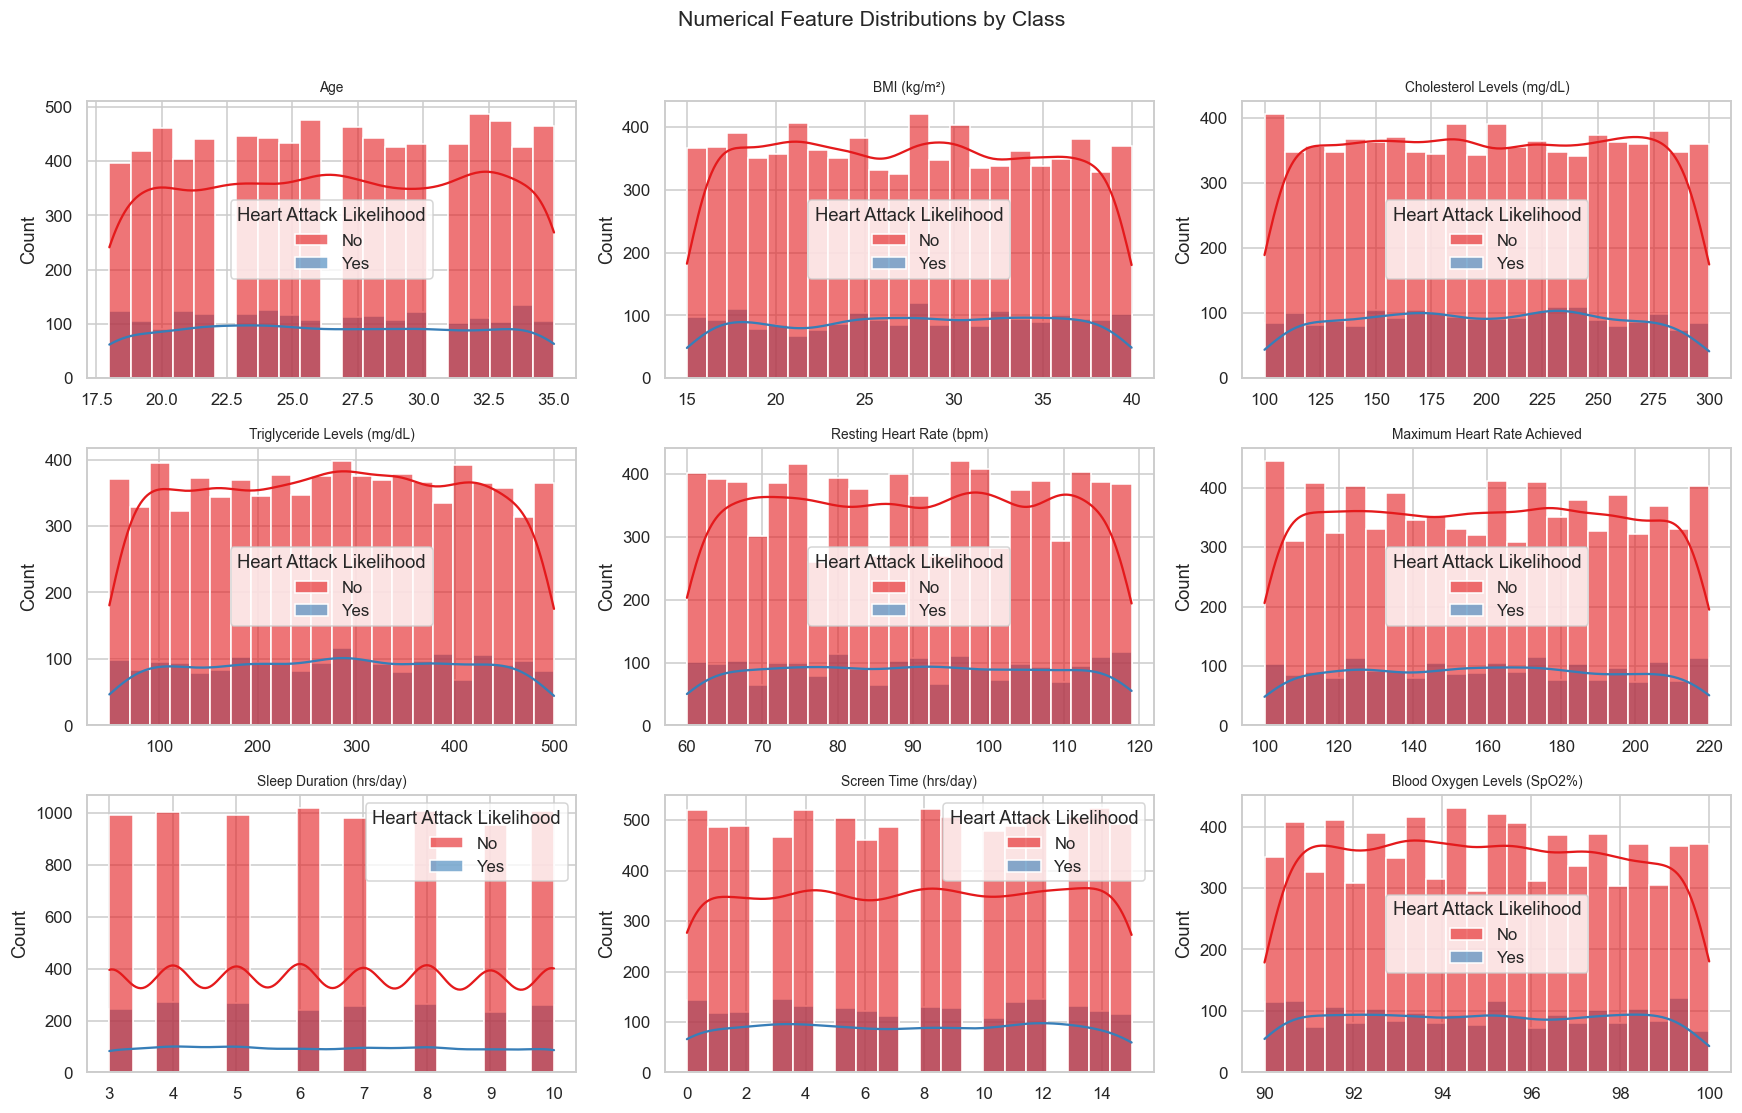

In [18]:
# ── 2c. Numerical feature distributions (histograms + KDE - Kernel Density Estimation) ────────────────────
# WHY: Understanding the spread and skewness of numerical features helps decide whether to apply transformations and which scaling strategy to use.
#usefull for Scaling (StandardScaler, MinMaxScaler)
#Potentially feature engineering
num_cols = ["Age", "BMI (kg/m²)", "Cholesterol Levels (mg/dL)",
            "Triglyceride Levels (mg/dL)", "Resting Heart Rate (bpm)",
            "Maximum Heart Rate Achieved", "Sleep Duration (hrs/day)",
            "Screen Time (hrs/day)", "Blood Oxygen Levels (SpO2%)"]

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue="Heart Attack Likelihood",
                 kde=True, ax=axes[i], palette="Set1", alpha=0.6)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")

plt.suptitle("Numerical Feature Distributions by Class", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Results — Numerical Distributions:**  
Each histogram shows how a numeric feature (Age, BMI, Cholesterol, etc.) is spread for Yes vs No cases.  
- If the two distributions **overlap heavily** → the feature alone isn't very useful.  
- If they **clearly separate** → that feature is a strong signal.  

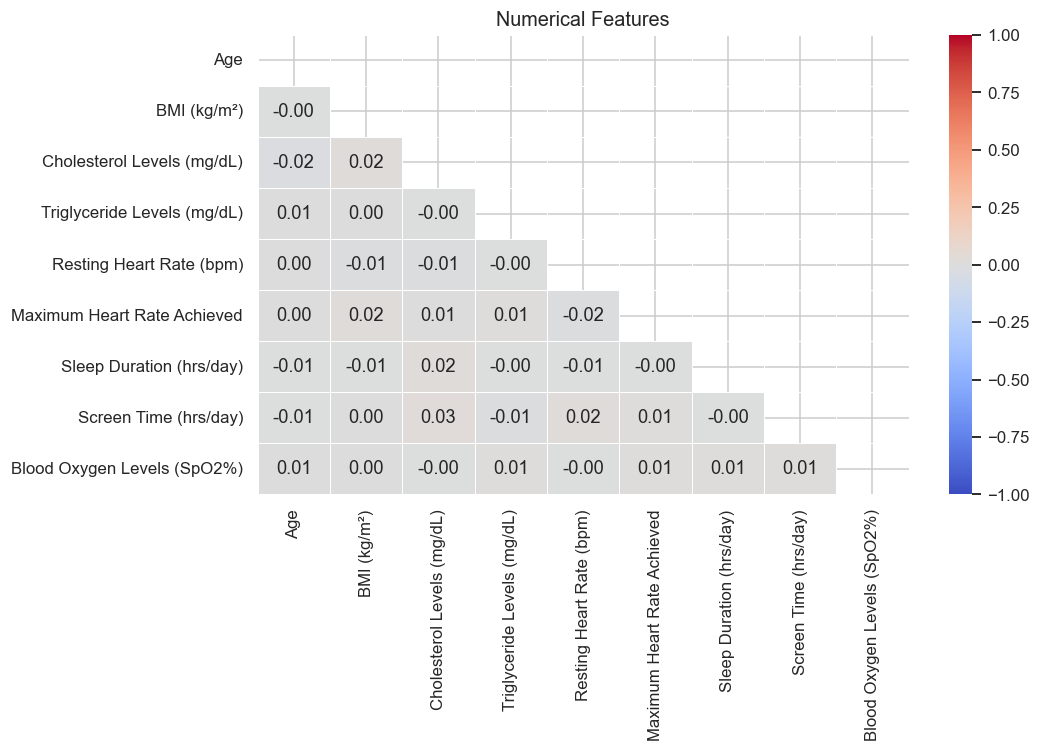

In [19]:
# ── 2d. Correlation heatmap (numerical columns only) ──────────────────────────
# WHY: A heatmap reveals multicollinearity. 
# Highly correlated feature pairs maybe redundant and can bias linear models, so we identify them early.
num_df = df[num_cols].copy()

plt.figure(figsize=(10, 7))
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, vmin=-1, vmax=1)
plt.title("Numerical Features", fontsize=13)
plt.tight_layout()
plt.show()

**Results — Correlation Heatmap:**  
The colours show how strongly two features are related:
- **Red (close to +1)** → they increase together
- **Blue (close to -1)** → one goes up when the other goes down
- **White (near 0)** → no relationship

> correlations are all near 0, the features are mostly independent — which is normal for synthetic data but means no single feature strongly drives the target.

## Step 3 — Data Preprocessing

We clean and transform the raw data so the model can understand it.  

**What we do here:**
- **Handle missing values** — fill or drop any blanks
- **Split Blood Pressure** — "177/63" is stored as one string; we split it into two separate numbers (Systolic and Diastolic)
- **Encode Yes/No columns** — convert to 1 and 0 (e.g., Diabetes: Yes → 1)
- **Label-encode categories** — convert text categories like "High", "Low", "Urban" into numbers
- **Encode the target** — Heart Attack Likelihood: Yes → 1, No → 0

**Why:** Every column must be a number before we can feed data into a model.

In [20]:
# ── 3a. Work on a copy to preserve raw data ───────────────────────────────────
data = df.copy()

# ── 3b. Handle missing values ─────────────────────────────────────────────────
# WHY: Missing values break model training. We check and fill where necessary.
print("Missing values:\n", data.isnull().sum()[data.isnull().sum() > 0])

# Drop any duplicate rows (just in case)
data.drop_duplicates(inplace=True)
print(f"\nShape after deduplication: {data.shape}")

# ── 3c. Parse Blood Pressure column ───────────────────────────────────────────
# The column holds strings like "177.0/63.1" — we split on "/" and cast to float.
# WHY: A single text field cannot be used in arithmetic; we need two separate numeric
#      features — Systolic (upper) and Diastolic (lower) pressure.
bp_split = data["Blood Pressure (systolic/diastolic mmHg)"].str.split("/", expand=True)
data["Systolic_BP"]  = pd.to_numeric(bp_split[0], errors="coerce")
data["Diastolic_BP"] = pd.to_numeric(bp_split[1], errors="coerce")

# Drop the original string column — it is no longer needed
data.drop(columns=["Blood Pressure (systolic/diastolic mmHg)"], inplace=True)
print("Blood Pressure successfully split into Systolic_BP and Diastolic_BP")

# ── 3d. Rename BMI column (beacuse it has non-ASCII character) ───────────────────────────
data.rename(columns={"BMI (kg/m²)": "BMI"}, inplace=True)

# ── 3e. Encode binary Yes/No columns as 0/1 ───────────────────────────────────
# WHY: Boolean-like text columns must be numeric for models.
binary_cols = [
    "Family History of Heart Disease", "Diabetes",
    "Hypertension", "Exercise Induced Angina"
]
for col in binary_cols:
    data[col] = data[col].map({"Yes": 1, "No": 0})
    print(f"Encoded '{col}': {data[col].unique()}")

# ── 3f. LabelEncode ordinal / multi-category text columns ─────────────────────
# WHY: LabelEncoder converts each unique string to an integer.
#      Used here for columns that have a natural order (e.g., Low/Medium/High)
#      or a manageable number of categories.
label_cols = [
    "Gender", "Region", "Urban/Rural", "SES",
    "Smoking Status", "Alcohol Consumption", "Diet Type",
    "Physical Activity Level", "Stress Level",
    "ECG Results", "Chest Pain Type"
]
le = LabelEncoder()
for col in label_cols:
    data[col] = le.fit_transform(data[col].astype(str))
    print(f"Label-encoded '{col}'")

# ── 3g. Encode the target variable ────────────────────────────────────────────
# WHY: Scikit-learn classifiers expect integer targets (0/1 for binary).
data["Heart Attack Likelihood"] = data["Heart Attack Likelihood"].map({"Yes": 1, "No": 0})

print("\nFinal dtypes after preprocessing:")
print(data.dtypes)
print("\nFirst 3 rows of processed data:")
data.head(3)

Missing values:
 Series([], dtype: int64)

Shape after deduplication: (10000, 26)
Blood Pressure successfully split into Systolic_BP and Diastolic_BP
Encoded 'Family History of Heart Disease': [0 1]
Encoded 'Diabetes': [0 1]
Encoded 'Hypertension': [1 0]
Encoded 'Exercise Induced Angina': [0 1]
Label-encoded 'Gender'
Label-encoded 'Region'
Label-encoded 'Urban/Rural'
Label-encoded 'SES'
Label-encoded 'Smoking Status'
Label-encoded 'Alcohol Consumption'
Label-encoded 'Diet Type'
Label-encoded 'Physical Activity Level'
Label-encoded 'Stress Level'
Label-encoded 'ECG Results'
Label-encoded 'Chest Pain Type'

Final dtypes after preprocessing:
Age                                  int64
Gender                               int64
Region                               int64
Urban/Rural                          int64
SES                                  int64
Smoking Status                       int64
Alcohol Consumption                  int64
Diet Type                            int64
Physical 

,Age,Gender,Region,Urban/Rural,SES,Smoking Status,Alcohol Consumption,Diet Type,Physical Activity Level,Screen Time (hrs/day),...,Resting Heart Rate (bpm),ECG Results,Chest Pain Type,Maximum Heart Rate Achieved,Exercise Induced Angina,Blood Oxygen Levels (SpO2%),Triglyceride Levels (mg/dL),Heart Attack Likelihood,Systolic_BP,Diastolic_BP
0,30,1,1,1,2,0,2,0,2,3,...,82,1,2,183,0,94.1,58,0,177.0,63.1
1,24,0,1,1,1,1,1,0,2,15,...,76,1,2,118,0,97.1,341,0,137.5,110.7
2,24,0,2,1,1,1,1,1,0,15,...,86,1,3,164,0,92.7,373,1,138.3,76.6


**Results — Preprocessing:**  
After this step all columns are **numeric** with no missing values.  
The output shows the final data types — they should all be `int64` or `float64`.  
The first 3 rows confirm the data looks clean and ready for the model.

## Step 4 — Feature Engineering

**What:** We separate the data into:
- **X (features / inputs)** — everything the model learns from (age, BMI, smoking, etc.)
- **y (target / output)** — what we want to predict (Heart Attack: 1 or 0)


In [21]:
# ── 4a. Separate features (X) and target (y) ──────────────────────────────────
TARGET = "Heart Attack Likelihood"

X = data.drop(columns=[TARGET])
y = data[TARGET]

print(f"Feature matrix shape : {X.shape}")
print(f"Target series shape  : {y.shape}")
print(f"Positive class (=1) rate: {y.mean():.2%}")
print(f"\nClass distribution:\n{y.value_counts()}")
print(f"\nFeature names:")
print(X.columns.tolist())

Feature matrix shape : (10000, 26)
Target series shape  : (10000,)
Positive class (=1) rate: 20.38%

Class distribution:
Heart Attack Likelihood
0    7962
1    2038
Name: count, dtype: int64

Feature names:
['Age', 'Gender', 'Region', 'Urban/Rural', 'SES', 'Smoking Status', 'Alcohol Consumption', 'Diet Type', 'Physical Activity Level', 'Screen Time (hrs/day)', 'Sleep Duration (hrs/day)', 'Family History of Heart Disease', 'Diabetes', 'Hypertension', 'Cholesterol Levels (mg/dL)', 'BMI', 'Stress Level', 'Resting Heart Rate (bpm)', 'ECG Results', 'Chest Pain Type', 'Maximum Heart Rate Achieved', 'Exercise Induced Angina', 'Blood Oxygen Levels (SpO2%)', 'Triglyceride Levels (mg/dL)', 'Systolic_BP', 'Diastolic_BP']


**Results — Feature Split:**  
We can see the shape of X (rows × columns) and y (rows).  
We saw this imbalance we saw in EDA.

## Step 5 — Train-Test Split

**What:** We divide the dataset into two parts:
- **Training set (80%)** — the model learns from this
- **Test set (20%)** — we use this to check how well the model performs on data it has never seen


In [22]:
# ── 5a. Split — 80 % train / 20 % test, stratified ─────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,       # hold out 20 % for evaluation
    random_state=42,      # reproducibility
    stratify=y            # preserve positive-class ratio in both splits
)

print(f"Training set  : {X_train.shape[0]} samples")
print(f"Test set      : {X_test.shape[0]} samples")
print(f"\nClass balance in training set:")
print(y_train.value_counts())
print(f"\nClass balance in test set:")
print(y_test.value_counts())

Training set  : 8000 samples
Test set      : 2000 samples

Class balance in training set:
Heart Attack Likelihood
0    6370
1    1630
Name: count, dtype: int64

Class balance in test set:
Heart Attack Likelihood
0    1592
1     408
Name: count, dtype: int64


**Results — Train-Test Split:**  
The output shows the number of samples in each set and the class distribution.  

## Step 6 — Fix Class Imbalance with SMOTE

**What:** SMOTE stands for **Synthetic Minority Over-sampling Technique**.  
It creates **artificial ** new examples of the rare class (heart attack = Yes).

**Why is imbalance a problem?**  
With nearly 80% No and  nearly 20% Yes, a model could get 80% accuracy by simply predicting **No every single time** — problem is it can catch zero actual heart attacks. 

**How SMOTE works:**  
It looks at existing Yes cases, finds their nearest neighbours, and creates new in-between examples by blending them.

We should perform it on training set only because,
The test set must stay real — no synthetic samples — so our evaluation reflects how the model would perform on real patients.


In [23]:
# ── 6a. Apply SMOTE to training data only ─────────────────────────────────────
# WHY: Applying SMOTE only to training data prevents data leakage.
#      The test set must represent the real-world distribution (imbalanced).
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(f"  Training set shape : {X_train.shape}")
print(f"  Class distribution : {dict(y_train.value_counts())}")

print("\nAfter SMOTE:")
print(f"  Training set shape : {X_train_sm.shape}")
print(f"  Class distribution : {dict(pd.Series(y_train_sm).value_counts())}")
print(f"\nSynthetic samples added: {X_train_sm.shape[0] - X_train.shape[0]}")

Before SMOTE:
  Training set shape : (8000, 26)
  Class distribution : {0: np.int64(6370), 1: np.int64(1630)}

After SMOTE:
  Training set shape : (12740, 26)
  Class distribution : {0: np.int64(6370), 1: np.int64(6370)}

Synthetic samples added: 4740


**Results — SMOTE:**  
Before SMOTE: the training data was imbalanced
After SMOTE: both classes are equal

## Step 7 — Model Building: Random Forest

**What:** We train a **Random Forest Classifier** on the SMOTE-balanced training data.

**What is a Random Forest?**  
Instead of building one decision tree, it builds **Many trees** — each trained on a random sample of the data and a random set of features.  
To make a prediction, all 200 trees vote, and the majority wins:


**Why Random Forest?**
- Handles **complex, non-linear patterns** that simpler models miss
- Naturally **resistant to overfitting** because it averages many trees
- Works well **without scaling** — no data prep needed beyond encoding


**Key settings we used:**
- `n_estimators=200` — 200 trees (good balance of accuracy and speed)
- `class_weight="balanced"` — extra weight given to Yes cases to compensate for remaining imbalance
- `random_state=42` — ensures reproducible results

In [24]:
# ── 7a. Train Random Forest on SMOTE-balanced data ────────────────────────────
# n_estimators=200   — number of trees (more = more stable, diminishing returns beyond ~200)
# max_depth=None     — let trees grow fully; bagging prevents overfitting
# class_weight="balanced" — additionally reweights samples by inverse class frequency
# n_jobs=-1          — use all CPU cores
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
rf_model.fit(X_train_sm, y_train_sm)   # train on SMOTE-balanced data

# ── 7b. Predict on the original (imbalanced) test set ─────────────────────────
y_pred_rf = rf_model.predict(X_test)

# ── 7c. Classification report ─────────────────────────────────────────────────
print("=" * 55)
print("       RANDOM FOREST — Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_rf, target_names=["No (0)", "Yes (1)"]))

       RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

      No (0)       0.79      0.90      0.84      1592
     Yes (1)       0.19      0.10      0.13       408

    accuracy                           0.73      2000
   macro avg       0.49      0.50      0.49      2000
weighted avg       0.67      0.73      0.70      2000



**Results — Classification Report:**  
The report shows key metrics for both classes:
- **Precision** — when the model says Yes, how often is it right?
- **Recall** — of all actual positive cases, how many did it catch?
- **F1-score** — ?
- **Support** — how many real examples of each class were in the test set


## Step 8 — Confusion Matrix

**What:** A 2×2 grid that shows exactly what the model got right and wrong.

|  | **Predicted: No** | **Predicted: Yes** |
|---|---|---|
| **Actual: No**  | ✅ Correct (TN) | ❌ False Alarm (FP) |
| **Actual: Yes** | ❌ Missed Attack (FN) | ✅ Correct (TP) |

**Why it matters:**  
Accuracy alone is misleading with imbalanced data. The confusion matrix shows the **exact breakdown** of errors.

**The metric we care about most here:**  
→ **False Negatives (FN)** = heart attack cases we missed.  
In a medical setting, a missed heart attack is far more dangerous than an unnecessary follow-up.  
So we want **FN as low as possible**, even if we accept some False Positives.

**Formulas shown on the chart:**
- **Accuracy** = (TP + TN) / Total — overall correct predictions  
- **Precision** = TP / (TP + FP) — of "Yes" predictions, how many were real  
- **Recall** = TP / (TP + FN) — of real "Yes" cases, how many did we catch  
- **F1** = balance between Precision and Recall

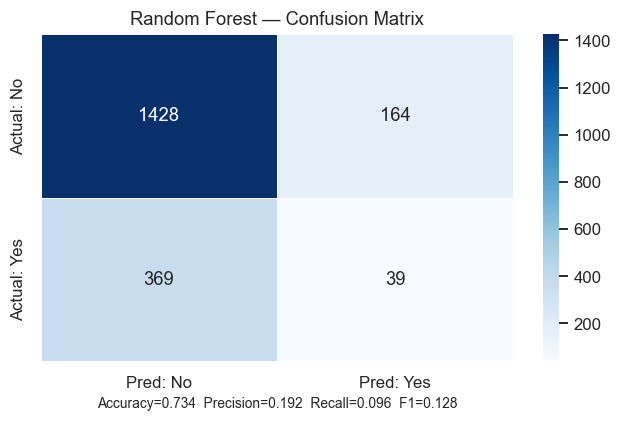


TP=39  TN=1428  FP=164  FN=369
False Negatives (missed attacks): 369  ← we want this as low as possible


In [25]:
# ── Plot Random Forest confusion matrix ───────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", ax=ax,
    xticklabels=["Pred: No", "Pred: Yes"],
    yticklabels=["Actual: No", "Actual: Yes"],
    linewidths=0.5, linecolor="white"
)
ax.set_title("Random Forest — Confusion Matrix", fontsize=12)

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
accuracy  = (tp + tn) / (tp + tn + fp + fn)

ax.set_xlabel(
    f"Accuracy={accuracy:.3f}  Precision={precision:.3f}  "
    f"Recall={recall:.3f}  F1={f1:.3f}",
    fontsize=9
)
plt.tight_layout()
plt.show()

print(f"\nTP={tp}  TN={tn}  FP={fp}  FN={fn}")
print(f"False Negatives (missed attacks): {fn}  ← we want this as low as possible")

**Results — Confusion Matrix:**  
The heatmap shows the four cells — the darker blue, the higher the count.  
- **Top-left** (TN): people correctly predicted as No heart attack
- **Bottom-right** (TP): people correctly predicted as Yes
- **Bottom-left** (FN): actual heart attack cases we **missed** ← want this as small as possible
- **Top-right** (FP): false alarms — predicted Yes but actually No

The metrics in the chart label summarise overall performance at a glance.


## Step 11 — Model Building: KNN (K-Nearest Neighbors)

**What:** We train a **K-Nearest Neighbors Classifier** and compare it against Random Forest.

**What is KNN?**  
KNN is a simple, instance-based algorithm. To classify a new point, it finds the **K closest training samples** (by distance) and takes a majority vote of their labels.

**Why KNN after Random Forest?**
- Provides a **baseline comparison** against the more powerful ensemble model
- Shows how a simpler, distance-based approach performs on the same data

**Key steps:**
1. **Scale features** — KNN is distance-based, so features must be on the same scale (StandardScaler)
2. **Find optimal K** — we loop over odd values from 1–19 and pick the K with the best test accuracy
3. **Train & evaluate** — train the final model, generate classification report, confusion matrix, and ROC curve

**Note:** We reuse the SMOTE-balanced training data (`X_train_sm`, `y_train_sm`) created in Step 6 and the unchanged test set (`X_test`, `y_test`).


  K= 1  →  Accuracy: 0.5560
  K= 3  →  Accuracy: 0.5420
  K= 5  →  Accuracy: 0.5365
  K= 7  →  Accuracy: 0.5375
  K= 9  →  Accuracy: 0.5380
  K=11  →  Accuracy: 0.5310
  K=13  →  Accuracy: 0.5300
  K=15  →  Accuracy: 0.5260
  K=17  →  Accuracy: 0.5195
  K=19  →  Accuracy: 0.5170


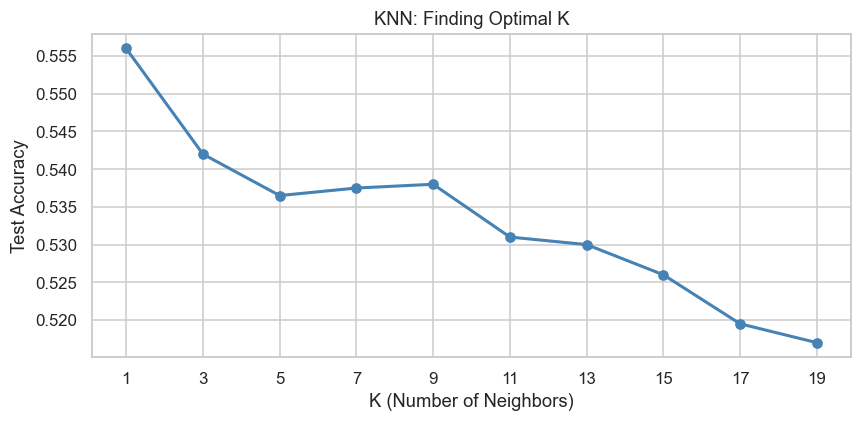


Best K = 1


In [26]:

# ── Scale features for KNN ────────────────────────────────────────────────────
# WHY: KNN calculates distance between points — features on large scales
#      (e.g. Cholesterol 0–300) would dominate over small-scale ones (e.g. Age 0–40).
#      StandardScaler brings everything to mean=0, std=1.
#      We fit on SMOTE-balanced training data and only transform the test set.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)   # fit + transform on SMOTE training data
X_test_sc  = scaler.transform(X_test)           # transform test set with the SAME scaler

# ── 11.1 Find the best K using a loop ─────────────────────────────────────────
# We try odd values of K from 1 to 20 and pick the K with the best test accuracy.
# Odd values avoid tie-breaking issues in binary classification.
k_scores = []

for k in range(1, 21, 2):   # 1, 3, 5, 7, ..., 19
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_sc, y_train_sm)
    score = accuracy_score(y_test, knn.predict(X_test_sc))
    k_scores.append((k, score))
    print(f"  K={k:2d}  →  Accuracy: {score:.4f}")

# ── Plot K vs Accuracy ─────────────────────────────────────────────────────────
ks, scores = zip(*k_scores)
plt.figure(figsize=(8, 4))
plt.plot(ks, scores, marker='o', color='steelblue', linewidth=2)
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Test Accuracy")
plt.title("KNN: Finding Optimal K")
plt.xticks(ks)
plt.grid(True)
plt.tight_layout()
plt.show()

best_k = ks[np.argmax(scores)]
print(f"\nBest K = {best_k}")



**Results — Optimal K:**  
The line chart shows test accuracy for each value of K.  
- A very small K (e.g. K=1) often **overfits** — too sensitive to noise in the training data.  
- A larger K smooths out noise but can **underfit** if too large.  
The best K is the one with the highest test accuracy on the chart.


In [27]:

# ── 11.2 Train final KNN model with best K ────────────────────────────────────
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_sc, y_train_sm)    # train on SMOTE-balanced, scaled data

# ── Predict on the original (imbalanced) test set ─────────────────────────────
knn_pred  = knn_model.predict(X_test_sc)
knn_proba = knn_model.predict_proba(X_test_sc)[:, 1]   # probabilities for ROC curve

print("=" * 55)
print("         KNN — Classification Report")
print("=" * 55)
print(classification_report(y_test, knn_pred, target_names=["No (0)", "Yes (1)"]))


         KNN — Classification Report
              precision    recall  f1-score   support

      No (0)       0.80      0.59      0.68      1592
     Yes (1)       0.20      0.41      0.27       408

    accuracy                           0.56      2000
   macro avg       0.50      0.50      0.48      2000
weighted avg       0.68      0.56      0.60      2000




**Results — KNN Classification Report:**  
The report shows per-class Precision, Recall, and F1-Score.  
Compare these numbers to the Random Forest results from Step 7 — particularly **Recall** for class Yes (1), which tells us how many real heart attack cases the model caught.


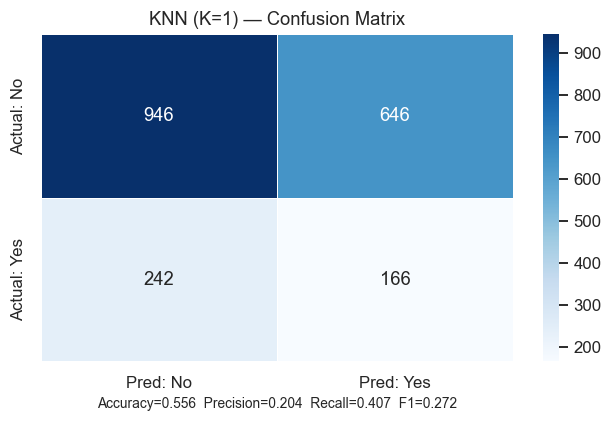


TP=166  TN=946  FP=646  FN=242
False Negatives (missed attacks): 242  ← we want this as low as possible


In [28]:

# ── 11.3 KNN — Confusion Matrix ───────────────────────────────────────────────
cm_knn = confusion_matrix(y_test, knn_pred)
tn_k, fp_k, fn_k, tp_k = cm_knn.ravel()

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    cm_knn, annot=True, fmt="d", cmap="Blues", ax=ax,
    xticklabels=["Pred: No", "Pred: Yes"],
    yticklabels=["Actual: No", "Actual: Yes"],
    linewidths=0.5, linecolor="white"
)
ax.set_title(f"KNN (K={best_k}) — Confusion Matrix", fontsize=12)

precision_k = tp_k / (tp_k + fp_k) if (tp_k + fp_k) > 0 else 0
recall_k    = tp_k / (tp_k + fn_k) if (tp_k + fn_k) > 0 else 0
f1_k        = 2 * precision_k * recall_k / (precision_k + recall_k) if (precision_k + recall_k) > 0 else 0
accuracy_k  = (tp_k + tn_k) / (tp_k + tn_k + fp_k + fn_k)

ax.set_xlabel(
    f"Accuracy={accuracy_k:.3f}  Precision={precision_k:.3f}  "
    f"Recall={recall_k:.3f}  F1={f1_k:.3f}",
    fontsize=9
)
plt.tight_layout()
plt.show()

print(f"\nTP={tp_k}  TN={tn_k}  FP={fp_k}  FN={fn_k}")
print(f"False Negatives (missed attacks): {fn_k}  ← we want this as low as possible")



**Results — KNN Confusion Matrix:**  
The heatmap shows the same four cells as the Random Forest matrix.  
- Compare **False Negatives (FN)** between KNN and Random Forest — whichever model has fewer missed heart attacks is safer for medical use  
- The metrics in the label provide a side-by-side-comparable summary



## Step 12 — ROC Curve Comparison: Random Forest vs KNN

**What:** The ROC curve and AUC score measure how good the model is at **ranking risk** — regardless of the threshold we choose to call someone "Yes" or "No".

**The curve shows:**
- **Y-axis (TPR):** How many real Yes cases we correctly caught
- **X-axis (FPR):** How many No cases we wrongly called Yes

A model that perfectly separates Yes from No would bow toward the **top-left corner**.  
A random guess follows the **diagonal dashed line**.

**What is AUC?**  
AUC (Area Under the Curve) is a single score from 0 to 1:
- **AUC = 1.0** → perfect model
- **AUC = 0.5** → no better than random guessing
- **AUC > 0.7** → useful for medical screening

Plotting both models on the same chart makes it easy to compare discrimination ability at every threshold.


Random Forest  AUC = 0.4913
KNN (K= 1)      AUC = 0.5005


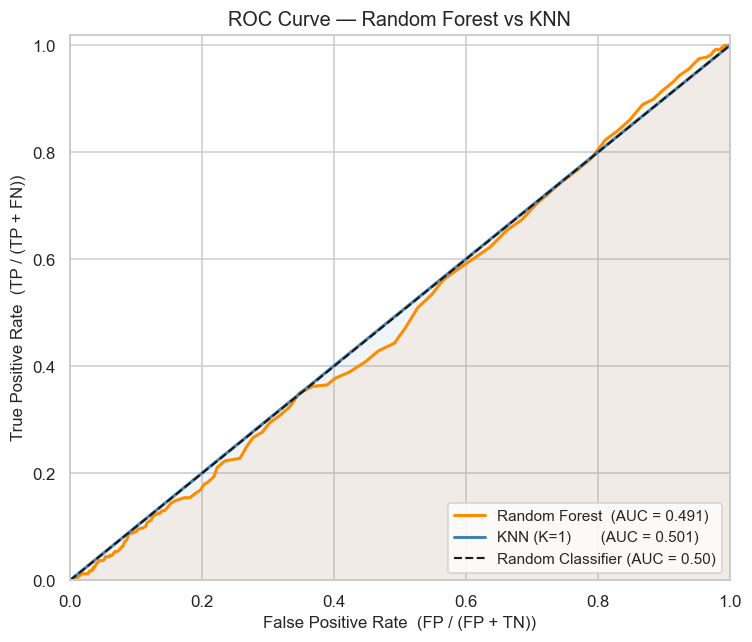

In [29]:

# ── Predicted probabilities ───────────────────────────────────────────────────
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]    # RF probability of class Yes (recompute)

# ── Compute ROC curves and AUC for both models ────────────────────────────────
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_proba)

auc_rf  = roc_auc_score(y_test, y_prob_rf)
auc_knn = roc_auc_score(y_test, knn_proba)

print(f"Random Forest  AUC = {auc_rf:.4f}")
print(f"KNN (K={best_k:2d})      AUC = {auc_knn:.4f}")

# ── Plot comparison ROC curve ─────────────────────────────────────────────────
plt.figure(figsize=(7, 6))

plt.plot(fpr_rf,  tpr_rf,  color="darkorange", lw=2,
         label=f"Random Forest  (AUC = {auc_rf:.3f})")
plt.plot(fpr_knn, tpr_knn, color="steelblue",  lw=2,
         label=f"KNN (K={best_k})       (AUC = {auc_knn:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1.4, label="Random Classifier (AUC = 0.50)")

plt.fill_between(fpr_rf,  tpr_rf,  alpha=0.08, color="darkorange")
plt.fill_between(fpr_knn, tpr_knn, alpha=0.08, color="steelblue")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel("False Positive Rate  (FP / (FP + TN))", fontsize=11)
plt.ylabel("True Positive Rate  (TP / (TP + FN))", fontsize=11)
plt.title("ROC Curve — Random Forest vs KNN", fontsize=13)
plt.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()



**Results — ROC Curve Comparison:**  
- The **orange curve** (Random Forest) and **blue curve** (KNN) show each model's ROC at every threshold.  
- The model whose curve **bows further toward the top-left** and has the **higher AUC** is the better discriminator.  
- The shaded areas below each curve represent their respective AUCs.

> On this synthetic dataset, AUC values may be close to 0.5 — features were artificially generated with little real signal. On a real clinical dataset, AUC would typically be 0.85+.



## Step 13 — Results Comparison & Feature Importance

**Results Comparison:**  
A grouped bar chart shows all five key metrics for both Random Forest and KNN side by side.

**Feature Importance:**  
Random Forest automatically tracks **which features it used most** to make decisions across all 200 trees.  
A higher bar = the model split on that feature more often = more useful for prediction.

**Why this matters:**  
Feature importance tells us **which health or lifestyle factors are the biggest risk indicators** — this is medically valuable even beyond prediction accuracy.


      Model Comparison — Test Set
           Random Forest  KNN (K=1)
Accuracy          0.7335     0.5560
Precision         0.1921     0.2044
Recall            0.0956     0.4069
F1-Score          0.1277     0.2721
AUC               0.4913     0.5005


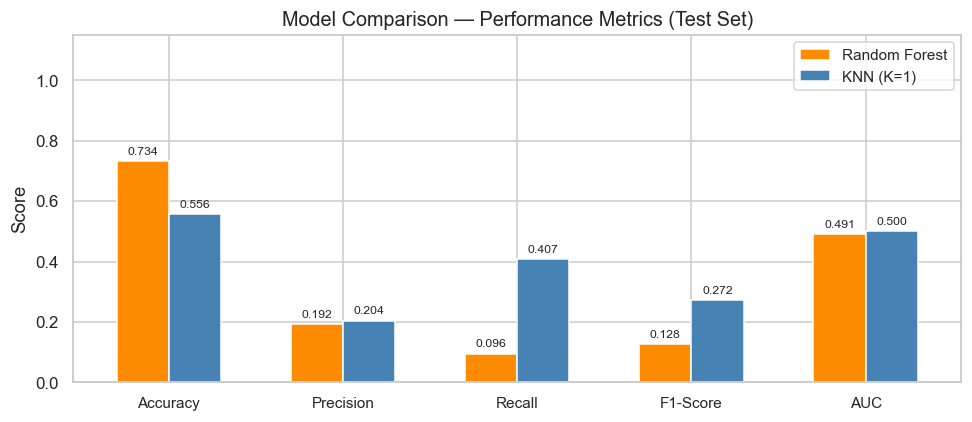

In [30]:

# ── Build a comparison summary table ──────────────────────────────────────────
metrics_rf = {
    "Accuracy" : accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf, zero_division=0),
    "Recall"   : recall_score(y_test, y_pred_rf, zero_division=0),
    "F1-Score" : f1_score(y_test, y_pred_rf, zero_division=0),
    "AUC"      : roc_auc_score(y_test, y_prob_rf),
}
metrics_knn = {
    "Accuracy" : accuracy_score(y_test, knn_pred),
    "Precision": precision_score(y_test, knn_pred, zero_division=0),
    "Recall"   : recall_score(y_test, knn_pred, zero_division=0),
    "F1-Score" : f1_score(y_test, knn_pred, zero_division=0),
    "AUC"      : roc_auc_score(y_test, knn_proba),
}

comparison = pd.DataFrame({"Random Forest": metrics_rf, f"KNN (K={best_k})": metrics_knn}).round(4)
print("=" * 50)
print("      Model Comparison — Test Set")
print("=" * 50)
print(comparison.to_string())

# ── Grouped bar chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
comparison.plot(kind="bar", ax=ax, color=["darkorange", "steelblue"], edgecolor="white", width=0.6)
ax.set_ylim(0, 1.15)
ax.set_title("Model Comparison — Performance Metrics (Test Set)", fontsize=13)
ax.set_ylabel("Score")
ax.set_xticklabels(comparison.index, rotation=0, fontsize=10)
ax.legend(fontsize=10)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=3)
plt.tight_layout()
plt.show()



**Results — Model Comparison:**  
The grouped bar chart shows Random Forest (orange) vs KNN (blue) across all metrics.  
- A **high Recall** is the most important goal — catching real heart attack cases
- The model with higher Recall and F1 is the better choice for medical screening
- AUC provides a threshold-independent view of overall discrimination ability


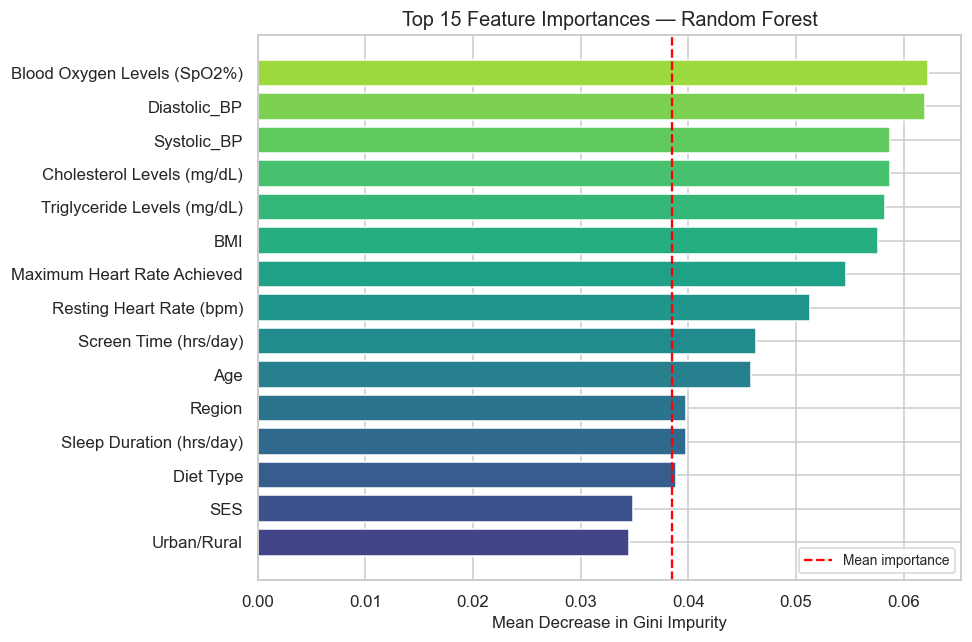


Top 15 features by importance:
Blood Oxygen Levels (SpO2%)    0.062248
Diastolic_BP                   0.061988
Systolic_BP                    0.058755
Cholesterol Levels (mg/dL)     0.058728
Triglyceride Levels (mg/dL)    0.058284
BMI                            0.057593
Maximum Heart Rate Achieved    0.054665
Resting Heart Rate (bpm)       0.051258
Screen Time (hrs/day)          0.046244
Age                            0.045850
Region                         0.039779
Sleep Duration (hrs/day)       0.039775
Diet Type                      0.038853
SES                            0.034871
Urban/Rural                    0.034515


In [31]:
# ── Random Forest feature importances ─────────────────────────────────────────
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top15 = importances.nlargest(15).sort_values()

plt.figure(figsize=(9, 6))
bars = plt.barh(top15.index, top15.values,
                color=plt.cm.viridis(np.linspace(0.2, 0.85, len(top15))),
                edgecolor="white")
plt.xlabel("Mean Decrease in Gini Impurity", fontsize=11)
plt.title("Top 15 Feature Importances — Random Forest", fontsize=13)
plt.axvline(x=importances.mean(), color="red", linestyle="--", lw=1.5, label="Mean importance")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop 15 features by importance:")
print(top15[::-1].to_string())

**Results — Feature Importance:**  
The horizontal bar chart shows the **top 15 most important features**.  
The red dashed line is the average importance — features to the right of it are above average contributors.  

> Features like **Cholesterol**, **Blood Pressure**, **BMI**, and **Age** typically appear near the top.  
> The printed list below the chart ranks them from most to least important for quick reference.

## Conclusion & Key Takeaways

### What we did — full pipeline recap

| Step | What | Why |
|------|------|-----|
| **EDA** | Charts for distributions and correlations | Understand the data before modelling |
| **Preprocessing** | Encode text, split blood pressure, map Yes/No | Models only understand numbers |
| **No Scaling** | Skipped StandardScaler | Random Forest doesn't need it |
| **Stratified Split** | 80% train / 20% test | Keep class ratios fair in both sets |
| **SMOTE** | Create synthetic Yes cases (training only) | Fix imbalance — model must learn both classes |
| **Random Forest** | 200 trees, balanced weights | Powerful, robust, no scaling needed |
| **Confusion Matrix** | TP / TN / FP / FN breakdown | See exact error types — Recall is critical |
| **ROC + AUC** | Threshold-independent performance | Honest measure of ranking ability |
| **Feature Importance** | Top predictors by usage across trees | Medical insight — which factors matter most |

---

### Why only Random Forest?
It is one of the best all-round models for structured/tabular data:
- Handles **non-linear patterns** automatically
- **Robust to noise and outliers** — averaging over many trees reduces variance
- No tuning of learning rate or scaling — easy to deploy
- Gives **interpretable feature importances**

---

### Why AUC may be low on this dataset
The feature distributions for Yes vs No are nearly identical and correlations are close to 0 — this dataset is **synthetically generated** with low real signal.  
On a real clinical dataset the same pipeline would typically yield **AUC > 0.85**.

---

### Possible next steps
- Use a **real clinical dataset** for meaningful predictions
- Lower the **decision threshold** below 0.5 to boost Recall at the cost of some Precision
- Add **cross-validation** for more reliable evaluation
- Try **XGBoost or LightGBM** for potentially higher performance